In [40]:
## The Python class of Bayes Net
## For this project, we assume that all RVs are Bernoulli, i.e. taking only True and False values under certain/no conditions
class BN:
      def __init__(self, cpts, net, domains):
        self.CPTS = cpts # all Conditional Probability Tables
        self.NET = net # net structure, parent-child relations
        self.DOMAINS = domains # what variables are in the net
        # Additions
        self.vars_sorted = self.topological_order()# Initialize the sorted list of variables immediately upon creation
        # This is to compute the children for each parent so that we do not need to scan the network everytime to find children
        self.children = {v: [] for v in self.DOMAINS}
        for child, parents in self.NET.items():
            if isinstance(parents, str): parents = (parents,)
            for p in parents:
                  self.children[p].append(child)
      
      def topological_order(self):
        """
        Orders variables such that parents appear before children. This is very important.
        This is required for Likelihood Weighting and Prior Sampling.
        """
        order = []
        visited = set()
        # We visit every parent to get the topological order.
        def visit(n):
            if n not in visited:
                parents = self.NET.get(n, [])
                # Ensure parents are treated as a tuple even if single string
                if isinstance(parents, str): parents = (parents,)
                for p in parents:
                    visit(p)
                visited.add(n)
                order.append(n)
        for node in self.DOMAINS:
            visit(node)
        return order

## A simply network with only 4 nodes
## suitable to verify the correctness of exact inference - Elimination-ASK
myCPTs = {
    'a': {'true': 0.3, 'false': 0.7},
    'b': {tuple(['true']): {'true': 0.3, 'false': 0.7},
          tuple(['false']): {'true': 0.7, 'false': 0.3}},
    'c': {tuple(['true']): {'true': 0.8, 'false': 0.2},
          tuple(['false']): {'true': 0.1, 'false': 0.9}},
    'd': {('false', 'false'): {'true': 0.3, 'false': 0.7},
          ('false', 'true'): {'true': 0.6, 'false': 0.4},
          ('true', 'false'): {'true': 0.5, 'false': 0.5},
          ('true', 'true'): {'true': 0.9, 'false': 0.1}}
}

myNet = {
    'a': tuple(),
    'b': ('a'),
    'c': ('a'),
    'd': ('b', 'c')
}

myDomains = {
    'a': ('true', 'false'),
    'b': ('true', 'false'),
    'c': ('true', 'false'),
    'd': ('true', 'false')
}

## The Burglar Network defined in our textbook
## Special because the net structure is a polytree
myCPTs2 = {
    'B': {'true': 0.001, 'false': 0.999},
    'E': {'true': 0.002, 'false': 0.998},
    'A': {('false', 'false'): {'true': 0.001, 'false': 0.999},
          ('false', 'true'): {'true': 0.29, 'false': 0.71},
          ('true', 'false'): {'true': 0.94, 'false': 0.06},
          ('true', 'true'): {'true': 0.95, 'false': 0.05}},
    'J': {tuple(['true']): {'true': 0.9, 'false': 0.1},
          tuple(['false']): {'true': 0.05, 'false': 0.95}},
    'M': {tuple(['true']): {'true': 0.7, 'false': 0.3},
          tuple(['false']): {'true': 0.01, 'false': 0.99}}      
}

myNet2 = {
    'B': tuple(),
    'E': tuple(),
    'A': ('B', 'E'),
    'J': ('A'),
    'M': ('A')
}

myDomains2 = {
    'B': ('true', 'false'),
    'E': ('true', 'false'),
    'A': ('true', 'false'),
    'J': ('true', 'false'),
    'M': ('true', 'false')
}

## a bigger network with 15 nodes
## Try different Queries on this net to evaluate your functions
myCPTs15 = {
    # Root nodes (priors)
    'B': {'true': 0.01, 'false': 0.99},          # Burglary
    'E': {'true': 0.02, 'false': 0.98},          # Earthquake
    'W': {'true': 0.05, 'false': 0.95},          # Weather alert
    'P': {'true': 0.1, 'false': 0.9},            # Power plant fault

    # Conditional nodes
    'A': {('false', 'false'): {'true': 0.001, 'false': 0.999},
          ('false', 'true'):  {'true': 0.29, 'false': 0.71},
          ('true',  'false'): {'true': 0.94, 'false': 0.06},
          ('true',  'true'):  {'true': 0.95, 'false': 0.05}},   # Alarm triggered by B or E

    'F': {('false', 'false'): {'true': 0.01, 'false': 0.99},
          ('false', 'true'):  {'true': 0.4, 'false': 0.6},
          ('true',  'false'): {'true': 0.6, 'false': 0.4},
          ('true',  'true'):  {'true': 0.8, 'false': 0.2}},     # Flood from W or E

    'T': {tuple(['true']):  {'true': 0.5, 'false': 0.5},
          tuple(['false']): {'true': 0.001, 'false': 0.999}},   # Tsunami from E

    'O': {('false', 'false'): {'true': 0.01, 'false': 0.99},
          ('false', 'true'):  {'true': 0.6, 'false': 0.4},
          ('true',  'false'): {'true': 0.3, 'false': 0.7},
          ('true',  'true'):  {'true': 0.9, 'false': 0.1}},     # Power outage from P or W

    'C': {tuple(['true']):  {'true': 0.8, 'false': 0.2},
          tuple(['false']): {'true': 0.05, 'false': 0.95}},     # Comm failure from O

    'J': {tuple(['true']):  {'true': 0.9, 'false': 0.1},
          tuple(['false']): {'true': 0.05, 'false': 0.95}},     # John calls from A

    'M': {tuple(['true']):  {'true': 0.7, 'false': 0.3},
          tuple(['false']): {'true': 0.01, 'false': 0.99}},     # Mary calls from A

    'V': {('false', 'false'): {'true': 0.01, 'false': 0.99},
          ('false', 'true'):  {'true': 0.6, 'false': 0.4},
          ('true',  'false'): {'true': 0.5, 'false': 0.5},
          ('true',  'true'):  {'true': 0.85, 'false': 0.15}},   # Traffic congestion from C or F

    'R': {('false', 'false'): {'true': 0.01, 'false': 0.99},
          ('false', 'true'):  {'true': 0.9, 'false': 0.1},
          ('true',  'false'): {'true': 0.8, 'false': 0.2},
          ('true',  'true'):  {'true': 0.95, 'false': 0.05}},   # Relief needed from F or T

    'S': {tuple(['true']):  {'true': 0.95, 'false': 0.05},
          tuple(['false']): {'true': 0.05, 'false': 0.95}},     # Shelters open from R

    'D': {('false', 'false'): {'true': 0.01, 'false': 0.99},
          ('false', 'true'):  {'true': 0.7, 'false': 0.3},
          ('true',  'false'): {'true': 0.9, 'false': 0.1},
          ('true',  'true'):  {'true': 0.85, 'false': 0.15}},   # Aid delivered from S or V
}

myNet15 = {
    'B': tuple(),
    'E': tuple(),
    'W': tuple(),
    'P': tuple(),
    'A': ('B', 'E'),
    'F': ('W', 'E'),
    'T': ('E',),
    'O': ('P', 'W'),
    'C': ('O',),
    'J': ('A',),
    'M': ('A',),
    'V': ('C', 'F'),
    'R': ('F', 'T'),
    'S': ('R',),
    'D': ('S', 'V')
}

myDomains15 = {
    'B': ('true', 'false'),
    'E': ('true', 'false'),
    'W': ('true', 'false'),
    'P': ('true', 'false'),
    'A': ('true', 'false'),
    'F': ('true', 'false'),
    'T': ('true', 'false'),
    'O': ('true', 'false'),
    'C': ('true', 'false'),
    'J': ('true', 'false'),
    'M': ('true', 'false'),
    'V': ('true', 'false'),
    'R': ('true', 'false'),
    'S': ('true', 'false'),
    'D': ('true', 'false')
}

## whichever network you want to use

myBN = BN(myCPTs, myNet, myDomains)
myBN2 = BN(myCPTs2, myNet2, myDomains2)
myBN3 = BN(myCPTs15, myNet15, myDomains15)



Test the Elimination_ASK algorithms with the 4 node network
{'true': 0.35924006908462863, 'false': 0.6407599309153714}

Testing the various algorithms
Exact Inference: {'true': 0.284171835364393, 'false': 0.7158281646356071}

Samples: 100
Likelihood Weighting: {'true': 0.0, 'false': 1.0}
Gibbs Sampling: {'true': 0.25, 'false': 0.75}

Samples: 500
Likelihood Weighting: {'true': 0.0, 'false': 1.0}
Gibbs Sampling: {'true': 0.28, 'false': 0.72}

Samples: 1000
Likelihood Weighting: {'true': 0.834990059642147, 'false': 0.165009940357853}
Gibbs Sampling: {'true': 0.29, 'false': 0.71}

Samples: 5000
Likelihood Weighting: {'true': 0.31335786751543654, 'false': 0.6866421324845634}
Gibbs Sampling: {'true': 0.2796, 'false': 0.7204}

Samples: 10000
Likelihood Weighting: {'true': 0.30382157926458997, 'false': 0.6961784207354101}
Gibbs Sampling: {'true': 0.2884, 'false': 0.7116}

Samples: 100000
Likelihood Weighting: {'true': 0.25139118146535705, 'false': 0.7486088185346429}
Gibbs Sampling: {'true': 

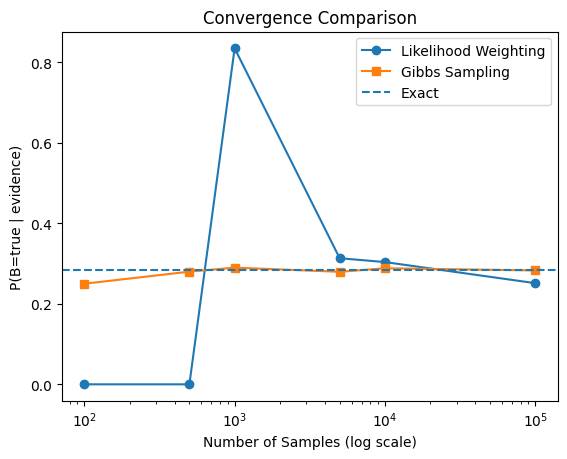

In [44]:
import numpy as np
import matplotlib.pyplot as plt



# Creating supporting functions make_factor, pointwise_product and sum_out.
def make_factor(var, e, bn):
    """Creates a factor table consistent with evidence."""
    parents = bn.NET[var]
    if isinstance(parents, str): parents = (parents,)
    vars_in_f = [var] + list(parents)
    table = {}
    
    # Generate all truth combinations for variables in the factor
    def gen(v_list):
        if not v_list: return [{}]
        first, rest = v_list[0], v_list[1:]
        values = [e[first]] if first in e else bn.DOMAINS[first]
    
        return [{**c, first: val} for val in values for c in gen(rest)]
    
    for config in gen(vars_in_f):
        val = config[var]

        if not parents:
            prob = bn.CPTS[var][val]
        else:
            p_vals = tuple(config[p] for p in parents)
            prob = bn.CPTS[var][p_vals][val]

        key = tuple(config[v] for v in vars_in_f)
        table[key] = prob

    return {'vars': vars_in_f, 'table': table}


def pointwise_product(f1, f2, bn):
    """Multiplies two factors."""
    new_vars = f1['vars'] + [v for v in f2['vars'] if v not in f1['vars']]
    new_table = {}

    for k1, v1 in f1['table'].items():
        assign1 = dict(zip(f1['vars'], k1))
        
        for k2, v2 in f2['table'].items():
            assign2 = dict(zip(f2['vars'], k2))
            
            # Check consistency
            if any(assign1[v] != assign2[v] for v in set(f1['vars']) & set(f2['vars'])):
                continue
            
            merged = {**assign1, **assign2}
            new_key = tuple(merged[v] for v in new_vars)
            new_table[new_key] = v1 * v2
    return {'vars': new_vars, 'table': new_table}
    


def sum_out(var, factors, bn):
    """Eliminates a variable from the factors list by summing it out."""
    involved = [f for f in factors if var in f['vars']]
    others = [f for f in factors if var not in f['vars']]
    if not involved: return others
    
    prod = involved[0]
    for f in involved[1:]: 
        prod = pointwise_product(prod, f, bn)
    
    new_vars = [v for v in prod['vars'] if v != var]
    v_idx = prod['vars'].index(var)
    new_table = {}
    for k, p in prod['table'].items():
        nk = k[:v_idx] + k[v_idx+1:]
        new_table[nk] = new_table.get(nk, 0) + p
    others.append({'vars': new_vars, 'table': new_table})
    return others


# The first algorithm is Exact Inference.
def elimination_ask(X, e, bn):
    """Exact inference using the Variable Elimination algorithm."""
    factors = []
    # Create a factor for every variable in the Bayes Net
    for var in bn.vars_sorted:
        factors.append(make_factor(var, e, bn))
    
    # Identify variables to sum out (hidden variables)
    hidden = [v for v in bn.vars_sorted if v != X and v not in e]
    for var in hidden:
        factors = sum_out(var, factors, bn)
    
    # Multiply remaining factors
    res = factors[0]
    for f in factors[1:]:
        res = pointwise_product(res, f, bn)
    
    # Normalize to get probability distribution
    probs = res['table']
    total = sum(probs.values())
    idx = res['vars'].index(X)
    return {k[idx]: v / total for k, v in probs.items()}



# The second algorithm is the Likelihood-weighting algorithm.
# approximate inference 1 - based on importance sampling
def likelihood_weighting(X, e, bn, N):
    """
    Estimates the probability P(X|e) using Importance Sampling.
    Unlike rejection sampling, it never 'throws away' a sample. Instead, it 
    fixes evidence variables and weights each sample by how likely the 
    evidence was to occur given its parents.
    """
    # Initialize a weight accumulator for each possible value of the query variable
    W = {val: 0.0 for val in bn.DOMAINS[X]}
    for _ in range(N):
        # Reset weight for this specific sample
        w, sample = 1.0, {}
        # Traverse the network in topological order
        for var in bn.vars_sorted:
            parents = bn.NET[var]
            if isinstance(parents, str): parents = (parents,)
            
            # Retrieve the CPT for the variable given its parents' sampled values
            p_vals = tuple(sample[p] for p in parents)
            cpt = bn.CPTS[var] if not parents else bn.CPTS[var][p_vals]

            if var in e:
                # If variable is evidence, fix its value to the observed state
                sample[var] = e[var]
                # Multiply the sample weight by the probability of the evidence occurring
                # w = w * P(evidence | parents)
                w *= cpt[e[var]]
            else:
                # If variable is not evidence, sample it normally from its distribution
                sample[var] = 'true' if np.random.rand() < cpt['true'] else 'false'

        # Add the final weight of this sample to the tally for the value of X
        W[sample[X]] += w
    
    # Normalize weights so the final distribution sums to 1.0
    total = sum(W.values())
    return {k: v / total for k, v in W.items()}



# The third algorithm is the Gibbs-ASK algorithm.
# approximate inference 2 - based on Gibbs sampling
def Gibbs_ASK(X, e, bn, N):
    """
    Estimates the probability P(X|e) using Markov Chain Monte Carlo (MCMC).
    It generates samples by walking through the state space, changing only one 
    variable at a time based on its Markov Blanket.
    """
    # Initialize frequency counts for the query variable
    counts = {val: 0 for val in bn.DOMAINS[X]}

    # Identify non-evidence variables that need to be sampled (Z)
    Z = [v for v in bn.vars_sorted if v not in e]

    # Initialize the state of the network (sample)
    # Evidence variables remain fixed; others are assigned random initial values
    sample = {**e, **{v: np.random.choice(bn.DOMAINS[v]) for v in Z}}
    
    for _ in range(N):
        for var in Z:
            # Re-sample 'var' conditioned on its Markov Blanket
            # P(var | MB) ∝ P(var | Parents) * Product(P(Child | Parents_of_Child))
            probs = {}
            for val in bn.DOMAINS[var]:
                temp = {**sample, var: val}

                # Part 1: Probability of the variable given its parents
                parents = bn.NET[var]
                if isinstance(parents, str): parents = (parents,)
                p_v = bn.CPTS[var][val] if not parents else bn.CPTS[var][tuple(temp[p] for p in parents)][val]
                
                # Part 2: Product of probabilities of all children given their parents
                p_children = 1.0
                for child in bn.children[var]:
                    node_parents = bn.NET[child]
                    if isinstance(node_parents, str):
                        node_parents = (node_parents,)
                    if var in node_parents:
                        # Find the conditional probability of the child node in the current temp state
                        p_children *= bn.CPTS[child][tuple(temp[p] for p in node_parents)][temp[child]]
                
                # Combine P(var|parents) and children's impact
                probs[val] = p_v * p_children

            # Normalize the calculated probabilities and sample a new value for the variable
            total = sum(probs.values())
            sample[var] = 'true' if np.random.rand() < (probs['true'] / total) else 'false'
        
        # Update the count for the current value of the query variable X
        counts[sample[X]] += 1
    # Final distribution is the relative frequency of values observed during the chain
    return {k: v / sum(counts.values()) for k, v in counts.items()}

# query variable
# Note: specifying 'true' or 'false' for the query variable X is unnecessary, because your elimination-ask and 
# all the other inference functions must answer the query as a vector, i.e. [P(X=true), P(X=false)]
# Just return your normalized vector

print("Test the Elimination_ASK algorithms with the 4 node network")

myX = 'a'
myE = {'d': 'true'} # evidence variables 
P_X = elimination_ask(myX, myE, myBN) 
print(P_X)


# ===============================
# Testing the various algorithms
# ===============================
print("\nTesting the various algorithms")

myX2 = 'B' 
myE2 = {'J': 'true', 'M': 'true'} # evidence variables


# Sample sizes to test convergence
sample_sizes = [100, 500, 1000, 5000, 10000, 100000]

# ===============================
# EXACT INFERENCE (GROUND TRUTH)
# ===============================
exact = elimination_ask(myX2, myE2, myBN2)
print("Exact Inference:", exact)

# ===============================
# RUN EXPERIMENTS
# ===============================
lw_results = []
gibbs_results = []

for N in sample_sizes:
    lw = likelihood_weighting(myX2, myE2, myBN2, N)
    gibbs = Gibbs_ASK(myX2, myE2, myBN2, N)

    lw_results.append(lw['true'])
    gibbs_results.append(gibbs['true'])

    print(f"\nSamples: {N}")
    print("Likelihood Weighting:", lw)
    print("Gibbs Sampling:", gibbs)

# ===============================
# ERROR ANALYSIS
# ===============================
exact_val = exact['true']

lw_errors = [abs(val - exact_val) for val in lw_results]
gibbs_errors = [abs(val - exact_val) for val in gibbs_results]

print("\nErrors (|approx - exact|):")
for i, N in enumerate(sample_sizes):
    print(f"N={N}: LW={lw_errors[i]:.4f}, Gibbs={gibbs_errors[i]:.4f}")

# ===============================
# PLOTTING CONVERGENCE
# ===============================
plt.figure()

plt.plot(sample_sizes, lw_results, marker='o', label="Likelihood Weighting")
plt.plot(sample_sizes, gibbs_results, marker='s', label="Gibbs Sampling")
plt.axhline(y=exact_val, linestyle='--', label="Exact")

plt.xscale('log')
plt.xlabel("Number of Samples (log scale)")
plt.ylabel(f"P({myX2}=true | evidence)")
plt.title("Convergence Comparison")
plt.legend()

plt.show()



--- Comparison Statistics (N=100) ---
Exponential Distribution (lambda=2):
  Estimated E(X): 0.4574 (True: 0.5)
  Estimated VAR(X): 0.1825 (True: 0.25)

Rejection Sampling (f(x)=|x|):
  Accepted: 100, Rejected: 98, Rejection Ratio: 0.4949
  Estimated E(X): 0.0163 (True: 0.0)
  Estimated VAR(X): 0.4996 (True: 0.5)

Box-Muller Transform (N(1, 4)):
  Estimated E(X): 1.1542 (True: 1)
  Estimated VAR(X): 3.8296 (True: 4)



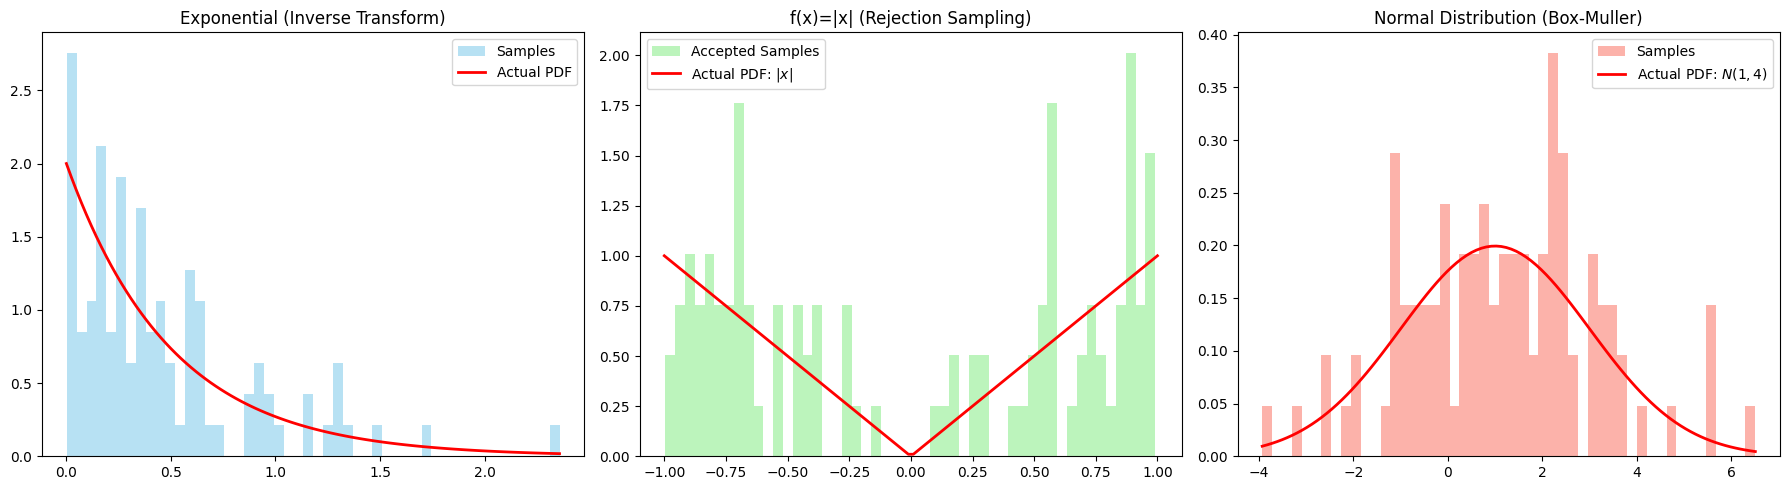

--- Comparison Statistics (N=1000) ---
Exponential Distribution (lambda=2):
  Estimated E(X): 0.4939 (True: 0.5)
  Estimated VAR(X): 0.2125 (True: 0.25)

Rejection Sampling (f(x)=|x|):
  Accepted: 1000, Rejected: 1088, Rejection Ratio: 0.5211
  Estimated E(X): -0.0198 (True: 0.0)
  Estimated VAR(X): 0.5070 (True: 0.5)

Box-Muller Transform (N(1, 4)):
  Estimated E(X): 0.9958 (True: 1)
  Estimated VAR(X): 4.1436 (True: 4)



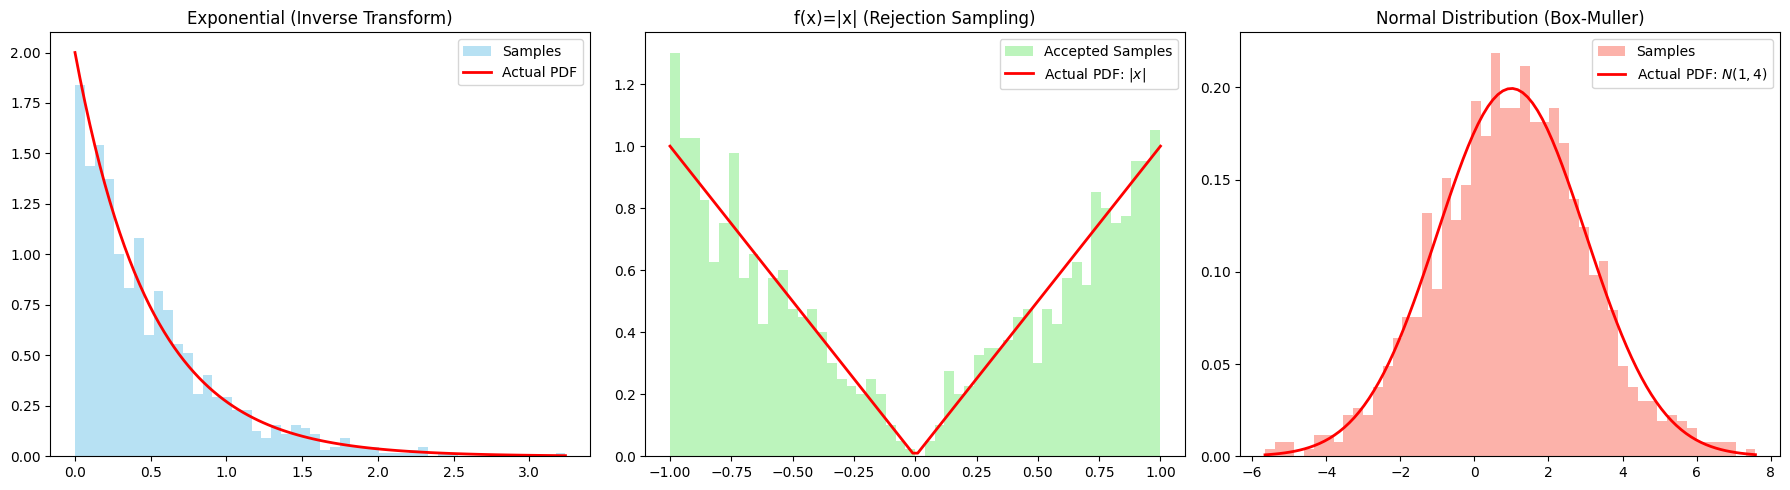

--- Comparison Statistics (N=10000) ---
Exponential Distribution (lambda=2):
  Estimated E(X): 0.4958 (True: 0.5)
  Estimated VAR(X): 0.2415 (True: 0.25)

Rejection Sampling (f(x)=|x|):
  Accepted: 10000, Rejected: 9997, Rejection Ratio: 0.4999
  Estimated E(X): -0.0077 (True: 0.0)
  Estimated VAR(X): 0.5000 (True: 0.5)

Box-Muller Transform (N(1, 4)):
  Estimated E(X): 1.0130 (True: 1)
  Estimated VAR(X): 3.9882 (True: 4)



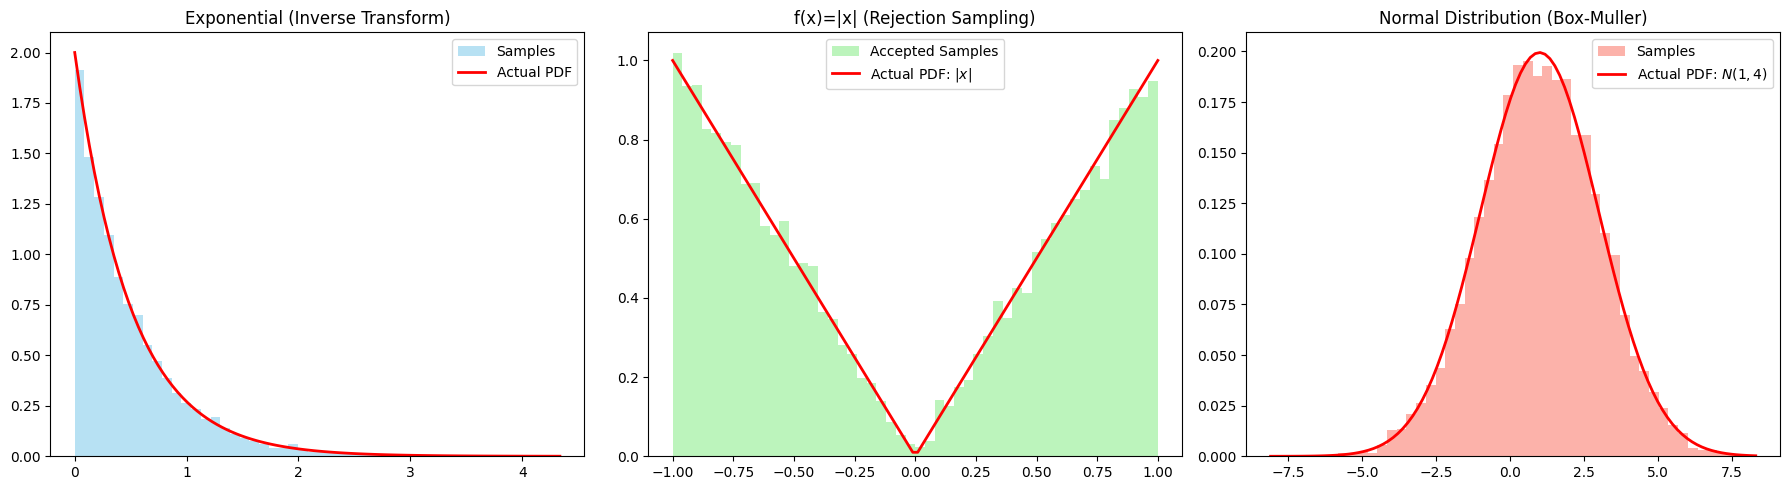

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# CONTINUOUS VARIABLE SAMPLING
# =============================================================================

def sample_exponential(N, lambd=2):
    """
    A. Inverse Transformative Sampling for Exponential Distribution.
    PDF: f(x) = lambda * e^(-lambda * x)
    CDF: F(x) = 1 - e^(-lambda * x)
    
    Logic:
    1. Set the CDF F(x) equal to a uniform random variable u ~ U(0,1).
    2. Solve for x: u = 1 - e^(-lambda * x)  =>  x = -ln(1-u) / lambda.
    """
    # Generate N uniform samples from the interval [0, 1)
    u = np.random.rand(N)
    
    # Transform uniforms into exponential samples using the inverse CDF
    # Note: Since u is uniform, (1-u) is also uniform, so -ln(u)/lambd works too.
    samples = -np.log(1 - u) / lambd
    
    # Theoretical Statistics for Exp(lambda=2)
    theoretical_mean = 1 / lambd
    theoretical_var = 1 / (lambd**2)
    
    return samples, theoretical_mean, theoretical_var

def sample_rejection(N):
    """
    B. Rejection Sampling for f(x) = |x| on [-1, 1].
    
    Logic:
    1. Define a proposal distribution g(x). We use Uniform(-1, 1).
    2. Find a constant M such that f(x) <= M * g(x) for all x.
       Target f(x) max is 1. Proposal g(x) height is 1/2 on [-1, 1].
       To cover the peak of |x| (which is 1), we need M * (1/2) = 1 => M = 2.
    3. Effectively, we sample a point (x, u) and accept if u is below the PDF curve.
    """
    accepted_samples = []
    rejected_count = 0
    
    # Continue sampling until we reach the desired number of accepted samples (N)
    while len(accepted_samples) < N:
        # Step 1: Generate a proposal x from the domain [-1, 1]
        x_proposal = np.random.uniform(-1, 1)
        
        # Step 2: Generate a vertical uniform sample u between 0 and M*g(x)
        # In this specific case, M*g(x) is a constant 1 (the max height of |x|)
        u_height = np.random.rand()
        
        # Step 3: Acceptance Check
        # Does the height 'u' fall under the target PDF curve |x|?
        if u_height <= abs(x_proposal):
            accepted_samples.append(x_proposal)
        else:
            rejected_count += 1
            
    samples = np.array(accepted_samples)
    accepted_count = len(samples)
    
    # Rejection Ratio = Total Rejections / (Total Attempts)
    rejection_ratio = rejected_count / (accepted_count + rejected_count)
    
    # Theoretical Statistics for f(x)=|x| on [-1, 1]
    theoretical_mean = 0.0  # Symmetric distribution centered at 0
    theoretical_var = 0.5   # Calculated by Integral of (x^2 * |x|) from -1 to 1
    
    return samples, theoretical_mean, theoretical_var, accepted_count, rejected_count, rejection_ratio

def sample_box_muller(N, mu=1, sigma=2):
    """
    C. Box-Muller Transformative Sampling for Normal Distribution N(1, 4).
    
    Logic:
    1. Take two independent uniforms u1, u2 ~ U(0, 1).
    2. Transform them into a standard normal Z ~ N(0, 1) using the polar form.
    3. Apply linear transformation: X = mu + sigma * Z to get N(mu, sigma^2).
    """
    u1 = np.random.rand(N)
    u2 = np.random.rand(N)
    
    # Box-Muller transformation formula to generate Standard Normal Z
    z0 = np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2)
    
    # Transform Z ~ N(0, 1) to X ~ N(1, 4)
    # Since Variance = 4, Sigma (Std Dev) = 2
    samples = mu + sigma * z0
    
    theoretical_mean = mu
    theoretical_var = sigma**2
    
    return samples, theoretical_mean, theoretical_var

# =============================================================================
# EVALUATION & VISUALIZATION
# =============================================================================

def compare_and_plot():
    """
    Executes all samplers, prints the comparative statistics, 
    and generates histograms overlaid with the true PDF curves.
    """
    sample_size = [100, 1000, 10000]

    for N in sample_size:
        # --- 1. Process Exponential ---
        s_exp, th_m_exp, th_v_exp = sample_exponential(N)
        
        # --- 2. Process Rejection ---
        s_rej, th_m_rej, th_v_rej, acc, rej, ratio = sample_rejection(N)
        
        # --- 3. Process Box-Muller ---
        s_norm, th_m_norm, th_v_norm = sample_box_muller(N)

        # --- Print Statistical Comparisons ---
        print(f"--- Comparison Statistics (N={N}) ---")
        print(f"Exponential Distribution (lambda=2):")
        print(f"  Estimated E(X): {np.mean(s_exp):.4f} (True: {th_m_exp})")
        print(f"  Estimated VAR(X): {np.var(s_exp):.4f} (True: {th_v_exp})\n")

        print(f"Rejection Sampling (f(x)=|x|):")
        print(f"  Accepted: {acc}, Rejected: {rej}, Rejection Ratio: {ratio:.4f}")
        print(f"  Estimated E(X): {np.mean(s_rej):.4f} (True: {th_m_rej})")
        print(f"  Estimated VAR(X): {np.var(s_rej):.4f} (True: {th_v_rej})\n")

        print(f"Box-Muller Transform (N(1, 4)):")
        print(f"  Estimated E(X): {np.mean(s_norm):.4f} (True: {th_m_norm})")
        print(f"  Estimated VAR(X): {np.var(s_norm):.4f} (True: {th_v_norm})\n")

        # --- Generate Plots ---
        plt.figure(figsize=(18, 5))

        # Plot Exponential Histogram
        plt.subplot(1, 3, 1)
        plt.hist(s_exp, bins=50, density=True, alpha=0.6, color='skyblue', label='Samples')
        x_e = np.linspace(0, max(s_exp), 100)
        plt.plot(x_e, 2 * np.exp(-2 * x_e), 'r', lw=2, label='Actual PDF')
        plt.title("Exponential (Inverse Transform)")
        plt.legend()

        # Plot Rejection Histogram
        plt.subplot(1, 3, 2)
        plt.hist(s_rej, bins=50, density=True, alpha=0.6, color='lightgreen', label='Accepted Samples')
        x_r = np.linspace(-1, 1, 100)
        plt.plot(x_r, np.abs(x_r), 'r', lw=2, label='Actual PDF: $|x|$')
        plt.title("f(x)=|x| (Rejection Sampling)")
        plt.legend()

        # Plot Box-Muller Histogram
        plt.subplot(1, 3, 3)
        plt.hist(s_norm, bins=50, density=True, alpha=0.6, color='salmon', label='Samples')
        x_n = np.linspace(min(s_norm), max(s_norm), 100)
        # PDF for Normal distribution N(mu=1, sigma=2)
        pdf_norm = (1 / (2 * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_n - 1) / 2)**2)
        plt.plot(x_n, pdf_norm, 'r', lw=2, label='Actual PDF: $N(1,4)$')
        plt.title("Normal Distribution (Box-Muller)")
        plt.legend()

        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    # Test with 100, 1000, 10,000 samples for the final comparison
    compare_and_plot()